exercises

In [2]:
# 1.2
import math

for x in 3, 3.14, 22 / 7:
    print(x - math.pi, (x - math.pi) / math.pi)

-0.14159265358979312 -0.04507034144862795
-0.0015926535897929917 -0.0005069573828972128
0.0012644892673496777 0.0004024994347707008


In [3]:
# 1.6
for x in .1, .5, 1:
    print(x - math.sin(x), math.asin(x) - x)

for x in .1, .5, 1:
    print(x - x ** 3 / 6 - math.sin(x), math.asin(x - x ** 3 / 6) - x)

0.0001665833531718508 0.00016742116155979425
0.020574461395796995 0.023598775598298927
0.1585290151921035 0.5707963267948966
-8.331349481138783e-08 -8.373180472587283e-08
-0.0002588719375363202 -0.0002949592406357171
-0.008137651474563135 -0.01488921666225429


In [4]:
# 1.7
# p, U, L
print(6,  3, -5)
print(6, -2, -2)

6 3 -5
6 -2 -2


In [5]:
# 1.8
# (a) 3

# (b) [-3, 0]

In [6]:
# 1.9
# (a)
r = 6370
4 * math.pi
12.57 * r
8007_0 * r
5100_00000

# (b)
r_head = r + 1
12.57 * r_head
8008_0 * r_head
5102_00000

# (c)
8 * math.pi
25.13 * r
1600_00

160000

In [7]:
# 1.9
# (d)
r = 6370
4 * math.pi
12.5664 * r
80048.0 * r
509906_000

r_head = r + 1
12.5664 * r_head
80060.5 * r_head
510065_000

8 * math.pi
25.1327 * r
160095
510065_000 - 509906_000
159000

# derivative more correct

159000

In [8]:
# 1.22
# (a)
a, b, c = 1.22, 3.34, 2.28
b * b, 4 * a
11.2, 4.88
4.88 * c
11.1
.1

# (b)
b * b - 4 * a * c
d = 0.029200000000001225

(.1 - d) / d

2.424657534246432

computer problems

In [9]:
# 1.1
def stirling(n):
    return math.sqrt(2 * math.pi * n) * (n / math.e) ** n


for n in range(1, 11):
    print(n, math.factorial(n), stirling(n), stirling(n) - math.factorial(n), (stirling(n) - math.factorial(n)) / math.factorial(n))


1 1 0.9221370088957891 -0.07786299110421091 -0.07786299110421091
2 2 1.9190043514889832 -0.08099564851101682 -0.04049782425550841
3 6 5.836209591345864 -0.16379040865413597 -0.027298401442355995
4 24 23.506175132893294 -0.4938248671067065 -0.020576036129446102
5 120 118.0191679575901 -1.9808320424099009 -0.016506933686749173
6 720 710.078184642185 -9.921815357815035 -0.013780299108076438
7 5040 4980.395831612462 -59.604168387538266 -0.011826223886416323
8 40320 39902.39545265671 -417.6045473432896 -0.010357255638474444
9 362880 359536.87284194835 -3343.1271580516477 -0.009212762230080598
10 3628800 3598695.6187410373 -30104.381258962676 -0.008295960443938127


In [10]:
# 1.2
# IEEE float p 24 L -126 U 127 subnormal -149
import numpy as np
p, L = 24, -126

epsilon = 1 / (1 << (p - 1))

epsilon == np.finfo(np.float32).eps

UFL = 1 / (1 << -L)
UFL == np.finfo(np.float32).tiny


def machine_epsilon(dtype):
    x = np.array(1, dtype=dtype)
    while 1 + x != 1:
        x /= 2
    return 2 * x # round to nearest


machine_epsilon(np.float32) == epsilon


def mantisa_bits(epsilon):
    return int(-np.log2(epsilon)) + 1


mantisa_bits(epsilon) == p


True

In [11]:
# 1.3

def approximate_machine_epsilon(dtype):
    return abs(3 * (np.float32(4).astype(dtype) / 3 - 1) - 1)


approximate_machine_epsilon(np.float32) == epsilon


double_epsilon = approximate_machine_epsilon(np.float64)
double_epsilon == np.finfo(np.float64).eps

approximate_machine_epsilon(np.float64) == double_epsilon


np.True_

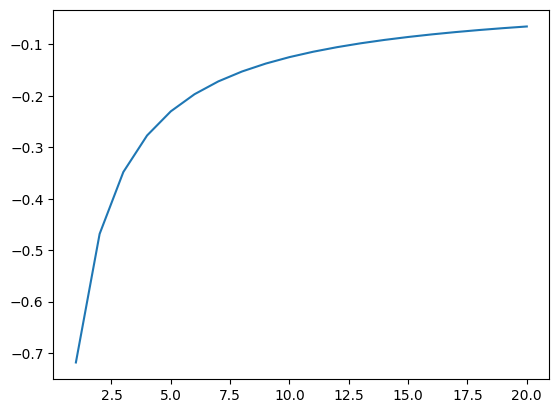

In [12]:
# 1.4
def value_e(n):
    return (1 + 1 / n) ** n


absolute_errors = [value_e(n) - np.e for n in range(1, 21)]
import matplotlib.pyplot as plt
plt.plot(range(1, 21), absolute_errors)

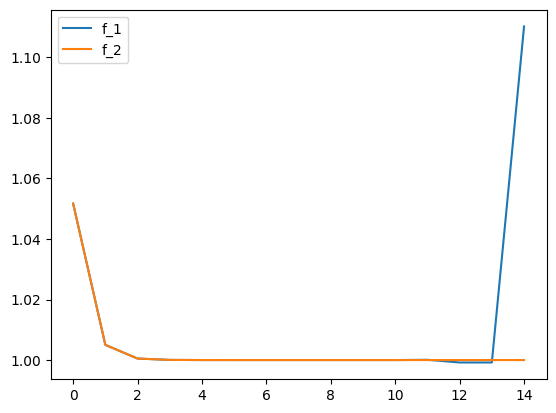

In [13]:
# 1.5
def f_1(x):
    return (np.exp(x) - 1) / x

def f_2(x):
    return (np.exp(x) - 1) / np.log(np.exp(x))


for f in f_1, f_2:
    plt.plot([f(10 ** -x) for x in range(1, 16)])

plt.legend(['f_1', 'f_2'])


(np.float64(2.220446049250313e-16), 1e-08)

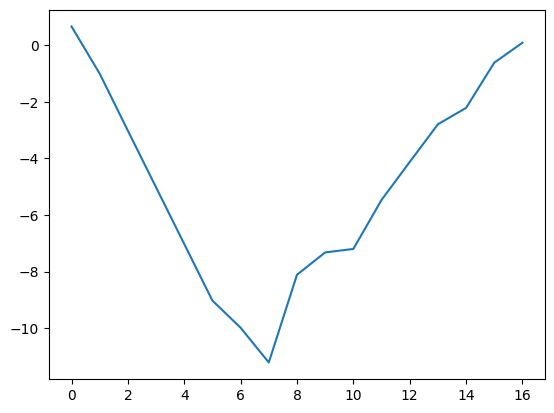

In [14]:
# 1.7

def derivative(f, h):
    return (f(1 + h) - f(1)) / h


def derivative(f, h):
    return (f(1 + h) - f(1 - h)) / (2 * h)


plt.plot(
    range(17),
    [np.log10(np.abs(derivative(np.tan, 10 ** (-i)) - 1 / np.cos(1) ** 2)) for i in range(17)]
)

np.finfo(np.float64).eps, 10 ** -8

In [15]:
# 1.8

def series():
    sum, n = np.array(0, dtype=np.float32), 1
    while sum != sum + 1 / n:
        sum += 1 / n
        n += 1
    return sum

series()

array(15.403683, dtype=float32)

In [16]:
# 1.9
def exponential(x):
    sum, n = np.array(1, dtype=np.float32), 1
    while sum != sum + x ** n / math.factorial(n):
        sum += x ** n / math.factorial(n)
        n += 1
    return sum


for sign in 1, -1:
    for x in 1, 5, 10, 15, 20:
        y = sign * x
        print(y, exponential(y), np.exp(y))


for sign in 1, -1:
    for x in 1, 5, 10, 15, 20:
        y = sign * x
        if sign > 0:
            print(y, exponential(y), np.exp(y))
        else:
            print(y, 1 / exponential(-y), np.exp(y))


1 2.718282 2.718281828459045
5 148.41318 148.4131591025766
10 22026.467 22026.465794806718
15 3269017.5 3269017.3724721107
20 485165200.0 485165195.4097903
-1 0.3678794 0.36787944117144233
-5 0.006737784 0.006737946999085467
-10 0.000110336485 4.5399929762484854e-05
-15 -0.01797611 3.059023205018258e-07
-20 -1.704205 2.061153622438558e-09
1 2.718282 2.718281828459045
5 148.41318 148.4131591025766
10 22026.467 22026.465794806718
15 3269017.5 3269017.3724721107
20 485165200.0 485165195.4097903
-1 0.36787942 0.36787944117144233
-5 0.006737946 0.006737946999085467
-10 4.5399927e-05 4.5399929762484854e-05
-15 3.0590232e-07 3.059023205018258e-07
-20 2.0611537e-09 2.061153622438558e-09


In [17]:
# 1.10
from numpy.polynomial import Polynomial


def quadratic_roots(a, b, c):
    max_value = max([abs(x) for x in (a, b, c)])
    a, b, c = a / max_value, b / max_value, c / max_value

    if a == 0:            
        return -c / b

    if c == 0:
        return sorted([0, -b / a])

    d = b * b - 4 * a * c

    if d >= 0:
        sqrt_d = math.sqrt(d)
        if -b * sqrt_d >= 0:
            return sorted([(-b + sqrt_d) / (2 * a), 2 * c / (-b + sqrt_d)])
        else:
            return sorted([(-b - sqrt_d) / (2 * a), 2 * c / (-b - sqrt_d)])
    else:
        sqrt_d = math.sqrt(-d)
        return [complex(-b / (2 * a), sqrt_d / (2 * a)), complex(-b / (2 * a), -sqrt_d / (2 * a))]
    

coefficients_list = [
    [6, 5, -4],
    [6 * 10 ** 154, 5 * 10 ** 154, -4 * 10 ** 154],
    [0, 1, 1],
    [1, -10 ** 5, 1],
    [1, -4, 3.999999],
    [10 ** (-155), - 10 ** (155), 10 * 155],
]

for coefficients in coefficients_list:
    p = Polynomial(coefficients[::-1])
    try:
        real_roots = p.roots()
    except:
        real_roots = 'Error'
    print(real_roots, quadratic_roots(*coefficients))

[-1.33333333  0.5       ] [-1.3333333333333333, 0.5]
Error [-1.3333333333333333, 0.5]
[-1.] -1.0
[1.e-05 1.e+05] [1.0000000001000001e-05, 99999.99999]
[1.999 2.001] [1.99899999999993, 2.00100000000007]
Error [1.55e-152, inf]


c:\Users\chuny\anaconda3\envs\py312\Lib\site-packages\numpy\polynomial\polynomial.py:1523: RuntimeWarning: overflow encountered in divide
  mat[:, -1] -= c[:-1]/c[-1]


In [18]:
# 1.11
import traceback


def cubic_roots(a, b, c):
    p = (3 * b - a * a) / 3
    q = 2 * a ** 3 / 27 - a * b / 3 + c
    D = (p / 3) ** 3 + (q / 2) ** 2

    if D > 0:
        return - a / 3 + np.cbrt(- q / 2 + np.sqrt(D)) + np.cbrt(- q / 2 - np.sqrt(D))

coefficients_list = [
    [6, 5, -4],
    [0, 1, 1],
    [1, -4, 3.999999],
]

for coefficients in coefficients_list:
    try:
        p = Polynomial(coefficients[::-1] + [1])
        try:
            real_roots = p.roots()
        except:
            real_roots = 'Error'
        print(real_roots, cubic_roots(*coefficients))
        # if cubic_roots(*coefficients):
        #     print(p(cubic_roots(*coefficients)))
    except:
        print('Error')


[-4.77845712 -1.71083145  0.48928857] None
[-0.6823278+0.j         0.3411639-1.1615414j  0.3411639+1.1615414j] -0.6823278038280194
[-2.87512973+0.j          0.93756486-0.71569082j  0.93756486+0.71569082j] -2.875129727712536


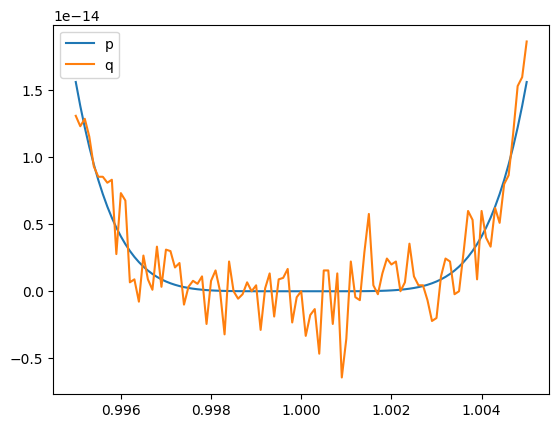

In [19]:
# 1.4
xs = np.linspace(.995, 1.005, 101)
ps = (xs - 1) ** 6

def polyval(coefficients, x):
    sum = 0
    for index, coefficient in enumerate(coefficients):
        sum += coefficient * x ** index
    return sum

qs = [polyval([1, -6, 15, -20, 15, -6, 1], x) for x in xs]

plt.plot(xs, ps, label='p')
plt.plot(xs, qs, label='q')
plt.legend()


In [20]:
# 1.16
np.random.seed(0)


def sum_1(xs):
    return sum(xs)


def sum_2(xs):
    return sum(xs.astype(np.float64))


def sum_3(xs):
    sum, c = 0, 0
    for x in xs:
        y = x - c
        t = sum + y
        c = (t - sum) - y
        sum = t
    return sum

def sum_4(xs):
    return sum(sorted(xs))


def sum_5(xs):
    return sum(sorted(xs, reverse=True))


for n in range(10):
    xs = np.random.rand(1 << n).astype(np.float32)
    print(1 << n, sum_1(xs), sum_2(xs), sum_3(xs), sum_4(xs), sum_5(xs))

1 0.5488135 0.54881352186203 0.5488135 0.5488135 0.5488135
2 1.3179526 1.3179526925086975 1.3179526 1.3179526 1.3179526
4 2.0520194 2.0520192980766296 2.0520194 2.0520194 2.0520194
8 5.1241746 5.124174430966377 5.1241746 5.124174 5.124174
16 8.655206 8.655205408111215 8.655206 8.655206 8.655207
32 14.212304 14.21230404265225 14.212304 14.212304 14.212304
64 31.592644 31.59264717530459 31.592648 31.592646 31.592646
128 63.321133 63.32113357819617 63.321133 63.321144 63.321136
256 126.40659 126.40663200989366 126.40663 126.406624 126.40658
512 252.56816 252.56809845298994 252.5681 252.5681 252.56818


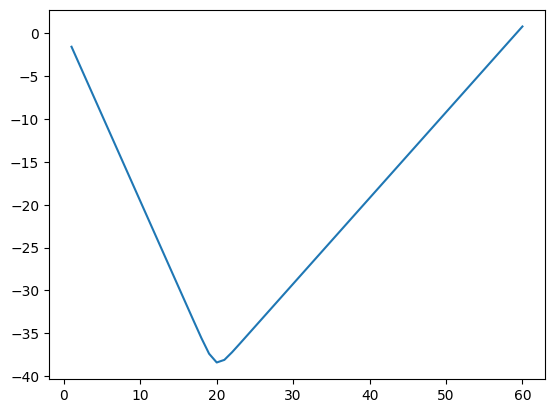

In [21]:
# 1.17
xs = np.zeros(60)
xs[:2] = 1 / 3, 1 / 12
for i in range(2, 60):
    xs[i] = 2.25 * xs[i - 1] - xs[i - 2] / 2

plt.plot(range(1, 61), np.log2(xs))

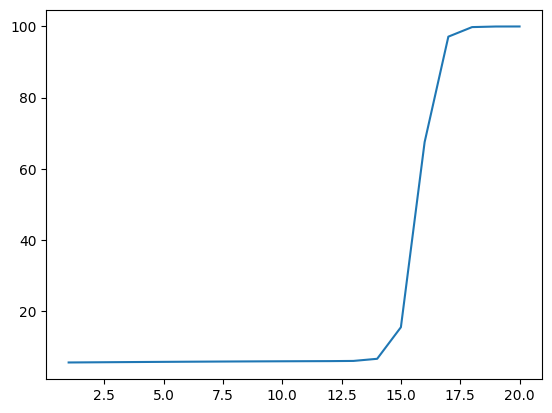

In [22]:
# 1.8
xs = np.zeros(20)
xs[:2] = 11 / 2, 61 / 11
for i in range(2, 20):
    xs[i] = 111 - (1130 - 3000 / xs[i - 2]) / xs[i - 1]

plt.plot(range(1, 21), xs)